# [Ex03] Data augmentation

1. MixUp과 CutMix 기법을 ResNet50 분류기에 성공적으로 적용하였는가?  
&rarr; MixUp과 CutMix를 적용한 데이터셋으로 훈련한 각각의 ResNet 모델이 수렴하였다.
2. 다양한 실험을 통해 태스크에 최적인 Augmentation 기법을 찾아내었는가?  
&rarr; 각 Augmentation 기법을 적용하고, 그에 따른 성능 비교 분석 및 문제점을 서술하였다.
3. 여러가지 Augmentation 기법을 적용한 결과를 체계적으로 비교분석하였는가?  
&rarr; 기본 Augmentation, MixUp, CutMix 가 적용된 결과를 시각화하여, 해석과 함께 체계적으로 분석하였다.

## 0. 라이브러리 import, GPU 확인, 하이퍼 파라미터 설정


In [1]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F

from torchvision.transforms import transforms
import torchvision.models as models

from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt

import gc

In [2]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
# 하이퍼 파라미터
BATCH_SIZE = 128
EPOCH = 20
LR = 0.001

## 1. 데이터 준비 및 전처리

### 1) 데이터 확인

#### (1) 샘플 시각화

In [4]:
DATA_PATH = "./data/Images/"

In [5]:
# 데이터 확인을 위한 transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [6]:
dataset = ImageFolder(root=DATA_PATH, transform=transform)
img_ex1 = plt.imread(dataset.imgs[164][0]) # dataset.imgs: 실제 이미지 파일 경로를 담고 있음
img_ex2 = plt.imread(dataset.imgs[456][0])
print(f"img_ex1.shape: {img_ex1.shape}, img_ex2.shape: {img_ex2.shape}")
# 원본 이미지는 사이즈 크기가 제각각임을 확인할 수 있음

img_ex1.shape: (448, 600, 3), img_ex2.shape: (322, 500, 3)


In [7]:
total_size = len(dataset)
print(total_size)

20580


In [8]:
# train:test = 0.583:0.417 비율로 split
train_size = int(total_size*0.583)
test_size = total_size - train_size
print(f"# of train data: {train_size}")
print(f"# of test data: {test_size}")
print(f"# of whole data: {train_size+test_size}")


# of train data: 11998
# of test data: 8582
# of whole data: 20580


In [9]:
trainset, testset = random_split(dataset, [train_size, test_size])

trainloader_for_show = DataLoader(dataset=trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader_for_show = DataLoader(dataset=testset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
ds_info = {
    "num_classes": len(dataset.classes), # 클래스 개수
    "class_names": dataset.classes # 클래스 이름
}

In [11]:
def show_examples(dataloader, class_names, num_imgs=6):
    imgs, labels = next(iter(dataloader))

    figs, axes = plt.subplots(1, num_imgs, figsize=(15,5))
    for i in range(num_imgs):
        img = imgs[i].permute(1,2,0).numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()
    

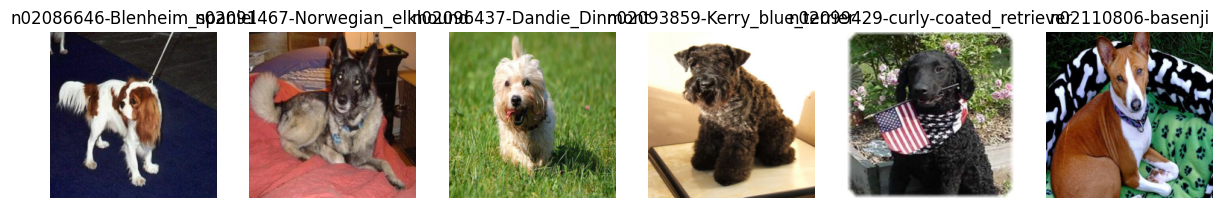

In [12]:
show_examples(trainloader_for_show, ds_info['class_names'])

### 2) 데이터 전처리 및 증강

#### (0) 공통 전처리

In [13]:
# 이미지를 224,224 크기로 조정하고
# 픽셀값을 0~1사이 값으로 변환 및 텐서로 변환
# 픽셀값에 normalize
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5,0.5,0.5],
            std=[0.5,0.5,0.5]
        )
    ])

#### (1) Basic Augmentation

In [14]:
def basic_augment():
    return transforms.Compose([        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=(0,180)), # 90도 단위 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 밝기, 대비, 색상        
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # 전체 픽셀의 0.8~1.0만큼만 남게 자르고 Resize
        transforms.Lambda(lambda img: torch.clamp(img, 0, 1)) # 각 픽셀이 0~1사이 값만 갖게
    ])

#### (2) MixUp

In [15]:
# function for mixup
def mixup_2_imgs(img_a, img_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 0~1 사이의 랜덤 값

    # 라벨 원핫 인코딩
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 이미지와 라벨 혼합
    mixed_img = (1 - ratio) * img_a + ratio * img_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_img, mixed_label

- for문 안에서 이미지를 하나하나 불러와서 연산이 느리고 비효율적
- 잘라내는 영역 조각조각을 메모리에 올려두기 때문에 메모리 이슈가 발생
(유리병에 모래부터 채워 넣어서 자갈이 들어갈 자리가 없는 것으로 이해함)

In [16]:
def mixup(imgs, labels, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    cur_batch_size = imgs.size(0)

    for i in range(cur_batch_size):
        img_a = imgs[i]
        label_a = labels[i]

        # 랜덤하게 다른 이미지 선택
        j = torch.randint(0, cur_batch_size, (1,)).item()
        img_b = imgs[j]
        label_b = labels[j]

        # Mixup 적용
        mixed_img, mixed_label = mixup_2_imgs(img_a, img_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 배치 차원 추가
    mixed_imgs = torch.stack(mixed_imgs) 
    mixed_labels = torch.stack(mixed_labels)
    # mixed_imgs = torch.stack(mixed_imgs).view(cur_batch_size, 3, img_size, img_size)  # (B, C, H, W)
    # mixed_labels = torch.stack(mixed_labels).view(cur_batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels

- 반복을 안 하고 batch 단위로 행렬 연산하여 한 번에 계산
- 복사본에 해당하는 데이터 하나만 메모리에 올려서 여유가 생김

In [17]:
def mixup_efficient(imgs, labels, alpha=1.0, num_classes=120):
    curr_batch_size = imgs.size(0)
    
    # 섞을 비율 결정 (배치 전체에 동일하게 적용하거나 각각 적용 가능)
    lam = np.random.beta(alpha, alpha)
    
    # 배치를 뒤섞을 인덱스 생성
    index = torch.randperm(curr_batch_size).to(imgs.device)
    
    # 리스트에 쌓지 않고 바로 행렬 연산 (In-place와 유사하게 동작) -> for문보다 훨씬 빠르고 메모리 효율적
    mixed_imgs = lam * imgs + (1 - lam) * imgs[index, :]
    
    # 라벨 섞기 (One-hot 변환 후 섞기)
    # labels가 이미 원핫이라면 바로 계산, 아니라면 여기서 변환    
    labels_a = F.one_hot(labels.to(torch.int64), num_classes=num_classes).float()
    labels_b = F.one_hot(labels[index].to(torch.int64), num_classes=num_classes).float()
    mixed_labels = lam * labels_a + (1 - lam) * labels_b
    
    return mixed_imgs, mixed_labels

#### (3) CutMix

In [18]:
def get_clip_box(img_a, img_b):
    '''
    이미지에서 잘라낼 영역인 bounding box 좌표를 구하는 함수
    '''
    # img.shape: Ch, H, W
    size_x = img_a.shape[2] # W
    size_y = img_a.shape[1] # H

    # center of box
    x = torch.randint(0, size_x, (1,)).item()
    y = torch.randint(0, size_y, (1,)).item()

    width = max(1, int(size_x*torch.sqrt(1-torch.rand(1)).item())) 
    height = max(1, int(size_y*torch.sqrt(1-torch.rand(1)).item()))

    # clip box in image and get minmax bbox
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = max(size_x, x + width // 2 + 1)
    y_max = max(size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

In [19]:
def mix_2_imgs(img_a, img_b, x_min, y_min, x_max, y_max):
    '''
    img_a: background image -> using outer area of bbox
    img_b: object image -> using inner area of bbox
    '''
    # img.shape: Ch, H, W
    size_x = img_a.shape[2]
    size_y = img_a.shape[1]

    if isinstance(img_a, np.ndarray):
        img_a = torch.from_numpy(img_a).to(device)
    if isinstance(img_b, np.ndarray):
        img_b = torch.from_numpy(img_b).to(device)

    top = img_a[:, :y_min, :]
    mid_left = img_a[:, y_min:y_max, :x_min]
    mid_center = img_b[:, y_min:y_max, x_min:x_max]
    mid_right = img_a[:, y_min:y_max, x_max:]
    bottom = img_a[:, y_max:, :]

    top = top.to(device)
    mid_left = mid_left.to(device)
    mid_center = mid_center.to(device)
    mid_right = mid_right.to(device)
    bottom = bottom.to(device)

    # 중간 부분 결합(왼쪽, 중앙, 오른쪽)
    mid = torch.cat([mid_left, mid_center, mid_right], dim=2)
    # 전체 이미지 결합(위, 중간, 아래)
    mixed_img = torch.cat([top, mid, bottom], dim=1)

    return mixed_img

In [20]:
# mix two labels
def mix_2_labels(size_x, size_y, label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    img_size_x = size_x
    img_size_y = size_y

    # bbox 비율 계산
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = img_size_x * img_size_y
    ratio = mixed_area / total_area

    # one-hot vector 
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 비율에 따라 라벨 혼합
    mixed_label = (1-ratio) * label_a + ratio * label_b
    return mixed_label    

- for문 안에서 이미지를 하나하나 불러와서 연산이 느리고 비효율적
- 잘라내는 영역 조각조각을 메모리에 올려두기 때문에 메모리 이슈가 발생
(유리병에 모래부터 채워 넣어서 자갈이 들어갈 자리가 없는 것으로 이해함)

In [21]:
def cutmix(imgs, labels, prob=1.0, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    curr_batch_size = imgs.size(0)


    for i in range(curr_batch_size):
        img_a = imgs[i]
        label_a = labels[i]

        j = torch.randint(0, curr_batch_size, (1,)).item() # 다른 샘플 선택
        img_b = imgs[j]
        label_b = labels[j]

        # bbox 생성
        x_min, y_min, x_max, y_max = get_clip_box(img_a, img_b)

        # 이미지 섞기
        mixed_imgs.append(mix_2_imgs(img_a, img_b, x_min, y_min, x_max, y_max))
        size_x, size_y = img_a.shape[2], img_a.shape[1]
        mixed_labels.append(mix_2_labels(size_x, size_y, label_a, label_b, x_min, y_min, x_max, y_max))

    # to tensor
    mixed_imgs = torch.stack(mixed_imgs).reshape(curr_batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(curr_batch_size, num_classes)

    return mixed_imgs, mixed_labels   

- 반복을 안 하고 batch 단위로 행렬 연산하여 한 번에 계산
- 복사본에 해당하는 데이터 하나만 메모리에 올려서 여유가 생김

In [ ]:
def cutmix_efficient(imgs, labels, alpha=1.0, num_classes=120):
    curr_batch_size = imgs.size(0)
    W = imgs.size(2)
    H = imgs.size(3)
    
    # 배치 내부 데이터를 뒤섞음
    index = torch.randperm(curr_batch_size).to(imgs.device)
    
    # 자를 비율(Lambda) 결정 (Beta 분포)
    lam = np.random.beta(alpha, alpha)
    
    # 3. 자를 박스의 좌표 계산 (중앙점 및 크기 결정)
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # 무작위 중앙점 선택
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    # 경계값 제한 (Clip)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    # 4. 이미지 합성 (원본 복사본 생성 후 특정 영역만 덮어쓰기)
    mixed_imgs = imgs.clone()
    mixed_imgs[:, :, bby1:bby2, bbx1:bbx2] = imgs[index, :, bby1:bby2, bbx1:bbx2]
    
    # 5. 실제 섞인 면적 비율 재계산 (정확한 Loss 계산을 위함)
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))

    # 6. 라벨 합성 (정수형 인덱스 -> 원-핫 행렬 변환 후 섞기)
    labels_a = F.one_hot(labels.to(torch.int64), num_classes=num_classes).float()
    labels_b = F.one_hot(labels[index].to(torch.int64), num_classes=num_classes).float()
    mixed_labels = lam * labels_a + (1 - lam) * labels_b

    return mixed_imgs, mixed_labels

### 3) 케이스 별 DataLoader 생성

In [23]:
# no_aug와 basic aug까지 반영해서 dataloader 반환
def build_dataloaders(dataset, batch_size=BATCH_SIZE, is_test=False, with_aug=False, method='no_aug'):
    common_transform = normalize_and_resize_img() # 모든 dataset에 다 적용해야 하는 전처리(normalize, resize)
    basic_transform = basic_augment()    

    # test dataset
    if is_test:
        assert not with_aug and method == 'no_aug', "test dataset에는 적용하지 않습니다."
        dataset.dataset.transform = common_transform
        
    else: # train dataset
        # 다른 방법을 입력하면 오류 출력
        assert method in ['no_aug', 'basic', 'mixup', 'cutmix'], "augmentation 방법을 확인하세요."
        if with_aug:            
            if method in ['basic', 'mixup', 'cutmix']:
                dataset.dataset.transform = transforms.Compose([
                    *common_transform.transforms,                    
                    *basic_transform.transforms,                    
                ])                        
            else:
                print("augmentation 방법을 확인하세요.")
        else: # no_aug            
            dataset.dataset.transform = common_transform
            

    if is_test:
        print(f"test dataset, aug 적용: {with_aug}, method: {method}, batch_size: {batch_size}")
    else:
        print(f"train dataset, aug 적용: {with_aug}, method: {method}, batch_size: {batch_size}")    

    return DataLoader(dataset=dataset, batch_size=batch_size, shuffle= not is_test, num_workers=4, pin_memory=True)  

In [24]:
# train dataloader

# dataloader without augmentation
trainloader_wo_aug = build_dataloaders(trainset, with_aug=False)
# dataloader with basic augmentation
trainloader_basig_aug = build_dataloaders(trainset, with_aug=True, method='basic')
# dataloader with MixUp augmentation
trainloader_mixup_aug = build_dataloaders(trainset, with_aug=True, method='mixup')
# dataloader with MixUp augmentation
trainloader_cutmix_aug = build_dataloaders(trainset, with_aug=True, method='cutmix')

train dataset, aug 적용: False, method: no_aug, batch_size: 128
train dataset, aug 적용: True, method: basic, batch_size: 128
train dataset, aug 적용: True, method: mixup, batch_size: 128
train dataset, aug 적용: True, method: cutmix, batch_size: 128


In [25]:
# test dataloader

testloader = build_dataloaders(testset, is_test=True)

test dataset, aug 적용: False, method: no_aug, batch_size: 128


## 2. 모델 학습

In [35]:
# 모델 학습 하는 함수

def train(model, trainloader, testloader, batch_size, criterion, optimizer, epochs, mixup_or_cutmix=None):
    model.to(device)
    history = {'train_loss':[], 'val_loss': [], 'val_acc':[]}

    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.
        correct = 0
        total = 0

        for i, (imgs, labels) in enumerate(trainloader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()

            if mixup_or_cutmix == "mixup": # mixup을 사용할 때 img, label 변환
                mixup_imgs, mixup_labels = mixup_efficient(imgs, labels, num_classes=120)
                mixup_labels = mixup_labels.float()
                mixup_imgs, mixup_labels = mixup_imgs.to(device), mixup_labels.to(device)
                outputs = model(mixup_imgs).float()
                loss = criterion(outputs, mixup_labels)
            elif mixup_or_cutmix == "cutmix": # cutmix를 사용할 때 img, label 변환
                cutmix_imgs, cutmix_labels = cutmix_efficient(imgs, labels, num_classes=120)
                cutmix_imgs, cutmix_labels = cutmix_imgs.to(device), cutmix_labels.to(device)
                outputs = model(cutmix_imgs)
                loss = criterion(outputs, cutmix_labels)            
            else: # 그 외의 경우
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, pred = torch.max(outputs, dim=1)
            total += len(labels)
            correct += pred.eq(labels).sum().item()
            # correct += (pred==labels).sum().item()
               
            if i == len(trainloader)-1: # 마지막 배치 통과 시 출력
                print(f"[Epoch: {epoch + 1}, {i + 1:4d}th batch] loss: {running_loss / (i + 1):.3f}")            

        train_loss = running_loss / len(trainloader)
        history['train_loss'].append(train_loss)
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs}, Train Accuracy: {train_acc*100:.2f}%")

        model.eval()
        correct = 0
        total = 0
        val_running_loss = 0.
        with torch.no_grad():
            for imgs, labels in testloader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)

                v_loss = criterion(outputs, labels)

                _, pred = outputs.max(dim=1)
                total += len(labels)
                correct += pred.eq(labels).sum().item()
                
                val_running_loss += v_loss.item()

        val_loss = val_running_loss / len(testloader)
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"Validation Accuracy: {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc            
            # torch.save(model.state_dict(), save_path)            

    print("-"*20)
    print(f"*****Training Finished*****")
    print(f"Best Val Acc: {best_val_acc*100:.2f}%")
    print("-"*20)

    return history

### 1) 케이스 별 모델 생성

In [36]:
num_classes = len(ds_info['class_names'])

In [37]:
# ResNet50 Model Without Augmentation
resnet50_wo_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_wo_aug.fc = nn.Linear(resnet50_wo_aug.fc.in_features, num_classes)

In [38]:
# ResNet50 Model With Basic Augmentation
resnet50_basic_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_basic_aug.fc = nn.Linear(resnet50_basic_aug.fc.in_features, num_classes)

In [39]:
# ResNet50 Model With MixUp Augmentation
resnet50_mixup_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_mixup_aug.fc = nn.Linear(resnet50_mixup_aug.fc.in_features, num_classes)

In [40]:
# ResNet50 Model With CutMix Augmentation
resnet50_cutmix_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_cutmix_aug.fc = nn.Linear(resnet50_cutmix_aug.fc.in_features, num_classes)

### 2) 모델 학습

In [ ]:
# Out of Memory 에러 방지를 위해, 메모리에서 다쓴 모델과 optimizer를 삭제
def clean_memory(model, optimizer):
    del model
    del optimizer
    gc.collect()
    torch.cuda.empty_cache()
    print("model, optimizer 삭제")

In [42]:
criterion = nn.CrossEntropyLoss()

In [43]:
optimizer_wo_aug = optim.SGD(resnet50_wo_aug.parameters(), lr = LR)
results_wo_aug = train(resnet50_wo_aug, trainloader_wo_aug, testloader, batch_size=BATCH_SIZE, 
                       criterion=criterion, optimizer=optimizer_wo_aug, epochs=EPOCH, mixup_or_cutmix=None)

clean_memory(resnet50_wo_aug, optimizer_wo_aug)

[Epoch: 1,   94th batch] loss: 4.781
Epoch 1/20, Train Accuracy: 1.44%
Validation Accuracy: 3.20%
[Epoch: 2,   94th batch] loss: 4.643
Epoch 2/20, Train Accuracy: 4.82%
Validation Accuracy: 8.28%
[Epoch: 3,   94th batch] loss: 4.511
Epoch 3/20, Train Accuracy: 12.33%
Validation Accuracy: 16.52%
[Epoch: 4,   94th batch] loss: 4.376
Epoch 4/20, Train Accuracy: 21.18%
Validation Accuracy: 24.48%
[Epoch: 5,   94th batch] loss: 4.236
Epoch 5/20, Train Accuracy: 29.21%
Validation Accuracy: 31.13%
[Epoch: 6,   94th batch] loss: 4.088
Epoch 6/20, Train Accuracy: 36.12%
Validation Accuracy: 37.29%
[Epoch: 7,   94th batch] loss: 3.933
Epoch 7/20, Train Accuracy: 41.98%
Validation Accuracy: 42.45%
[Epoch: 8,   94th batch] loss: 3.773
Epoch 8/20, Train Accuracy: 46.55%
Validation Accuracy: 46.53%
[Epoch: 9,   94th batch] loss: 3.613
Epoch 9/20, Train Accuracy: 50.34%
Validation Accuracy: 49.85%
[Epoch: 10,   94th batch] loss: 3.454
Epoch 10/20, Train Accuracy: 53.28%
Validation Accuracy: 53.19%
[E

In [44]:
optimizer_basic_aug = optim.SGD(resnet50_basic_aug.parameters(), lr = LR)
results_basic_aug = train(resnet50_basic_aug, trainloader_basig_aug, testloader, batch_size=BATCH_SIZE, 
                          criterion=criterion, optimizer=optimizer_basic_aug, epochs=EPOCH, mixup_or_cutmix=None)

clean_memory(resnet50_basic_aug, optimizer_basic_aug)

[Epoch: 1,   94th batch] loss: 4.782
Epoch 1/20, Train Accuracy: 1.64%
Validation Accuracy: 2.83%
[Epoch: 2,   94th batch] loss: 4.650
Epoch 2/20, Train Accuracy: 4.33%
Validation Accuracy: 6.58%
[Epoch: 3,   94th batch] loss: 4.524
Epoch 3/20, Train Accuracy: 9.73%
Validation Accuracy: 12.97%
[Epoch: 4,   94th batch] loss: 4.392
Epoch 4/20, Train Accuracy: 17.69%
Validation Accuracy: 20.34%
[Epoch: 5,   94th batch] loss: 4.256
Epoch 5/20, Train Accuracy: 25.31%
Validation Accuracy: 27.99%
[Epoch: 6,   94th batch] loss: 4.111
Epoch 6/20, Train Accuracy: 32.61%
Validation Accuracy: 34.77%
[Epoch: 7,   94th batch] loss: 3.959
Epoch 7/20, Train Accuracy: 39.49%
Validation Accuracy: 40.39%
[Epoch: 8,   94th batch] loss: 3.802
Epoch 8/20, Train Accuracy: 44.72%
Validation Accuracy: 45.14%
[Epoch: 9,   94th batch] loss: 3.643
Epoch 9/20, Train Accuracy: 49.05%
Validation Accuracy: 49.20%
[Epoch: 10,   94th batch] loss: 3.482
Epoch 10/20, Train Accuracy: 52.67%
Validation Accuracy: 52.70%
[Ep

In [45]:
optimizer_mixup_aug = optim.SGD(resnet50_mixup_aug.parameters(), lr = LR)
results_mixup_aug = train(resnet50_mixup_aug, trainloader_mixup_aug, testloader, batch_size=BATCH_SIZE, criterion=criterion, 
                          optimizer=optimizer_mixup_aug, epochs=EPOCH, mixup_or_cutmix="mixup")

clean_memory(resnet50_mixup_aug, optimizer_mixup_aug)

[Epoch: 1,   94th batch] loss: 4.818
Epoch 1/20, Train Accuracy: 1.20%
Validation Accuracy: 2.18%
[Epoch: 2,   94th batch] loss: 4.748
Epoch 2/20, Train Accuracy: 1.43%
Validation Accuracy: 4.63%
[Epoch: 3,   94th batch] loss: 4.680
Epoch 3/20, Train Accuracy: 3.30%
Validation Accuracy: 8.63%
[Epoch: 4,   94th batch] loss: 4.629
Epoch 4/20, Train Accuracy: 4.39%
Validation Accuracy: 13.70%
[Epoch: 5,   94th batch] loss: 4.575
Epoch 5/20, Train Accuracy: 7.09%
Validation Accuracy: 17.73%
[Epoch: 6,   94th batch] loss: 4.514
Epoch 6/20, Train Accuracy: 8.63%
Validation Accuracy: 22.20%
[Epoch: 7,   94th batch] loss: 4.438
Epoch 7/20, Train Accuracy: 11.71%
Validation Accuracy: 27.11%
[Epoch: 8,   94th batch] loss: 4.370
Epoch 8/20, Train Accuracy: 14.97%
Validation Accuracy: 31.38%
[Epoch: 9,   94th batch] loss: 4.299
Epoch 9/20, Train Accuracy: 16.66%
Validation Accuracy: 34.64%
[Epoch: 10,   94th batch] loss: 4.240
Epoch 10/20, Train Accuracy: 17.74%
Validation Accuracy: 37.45%
[Epoch:

In [46]:
optimizer_cutmix_aug = optim.SGD(resnet50_cutmix_aug.parameters(), lr = LR)
results_cutmix_aug = train(resnet50_cutmix_aug, trainloader_cutmix_aug, testloader, batch_size=BATCH_SIZE, criterion=criterion, 
                          optimizer=optimizer_cutmix_aug, epochs=EPOCH, mixup_or_cutmix="cutmix")

clean_memory(resnet50_cutmix_aug, optimizer_cutmix_aug)

[Epoch: 1,   94th batch] loss: 4.801
Epoch 1/20, Train Accuracy: 1.08%
Validation Accuracy: 1.68%
[Epoch: 2,   94th batch] loss: 4.750
Epoch 2/20, Train Accuracy: 1.88%
Validation Accuracy: 3.54%
[Epoch: 3,   94th batch] loss: 4.707
Epoch 3/20, Train Accuracy: 3.00%
Validation Accuracy: 5.91%
[Epoch: 4,   94th batch] loss: 4.664
Epoch 4/20, Train Accuracy: 4.12%
Validation Accuracy: 8.84%
[Epoch: 5,   94th batch] loss: 4.612
Epoch 5/20, Train Accuracy: 7.03%
Validation Accuracy: 12.65%
[Epoch: 6,   94th batch] loss: 4.584
Epoch 6/20, Train Accuracy: 7.63%
Validation Accuracy: 16.28%
[Epoch: 7,   94th batch] loss: 4.526
Epoch 7/20, Train Accuracy: 11.19%
Validation Accuracy: 20.43%
[Epoch: 8,   94th batch] loss: 4.463
Epoch 8/20, Train Accuracy: 13.17%
Validation Accuracy: 25.39%
[Epoch: 9,   94th batch] loss: 4.420
Epoch 9/20, Train Accuracy: 14.32%
Validation Accuracy: 29.14%
[Epoch: 10,   94th batch] loss: 4.367
Epoch 10/20, Train Accuracy: 18.65%
Validation Accuracy: 33.52%
[Epoch: 

## 3. 성능 비교 및 결과 분석

### 1) Training Loss

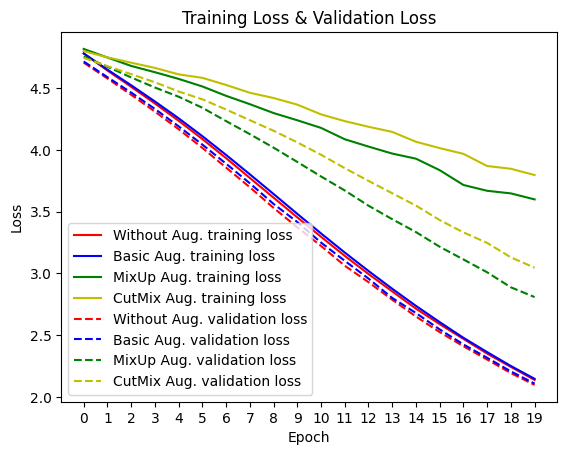

In [67]:
plt.plot(results_wo_aug['train_loss'], 'r', label="Without Aug. training loss")
plt.plot(results_basic_aug['train_loss'], 'b', label="Basic Aug. training loss")
plt.plot(results_mixup_aug['train_loss'], 'g', label="MixUp Aug. training loss")
plt.plot(results_cutmix_aug['train_loss'], 'y', label="CutMix Aug. training loss")

plt.plot(results_wo_aug['val_loss'], 'r', ls="--", label="Without Aug. validation loss")
plt.plot(results_basic_aug['val_loss'], 'b', ls="--", label="Basic Aug. validation loss")
plt.plot(results_mixup_aug['val_loss'], 'g', ls="--", label="MixUp Aug. validation loss")
plt.plot(results_cutmix_aug['val_loss'], 'y', ls="--", label="CutMix Aug. validation loss")

plt.title('Training Loss & Validation Loss')
plt.ylabel('Loss')
plt.xticks(list(range(EPOCH)))
plt.xlabel('Epoch')
plt.legend(loc='lower left')
plt.savefig('loss.png')
plt.show()

### 2) Validation Accuracy

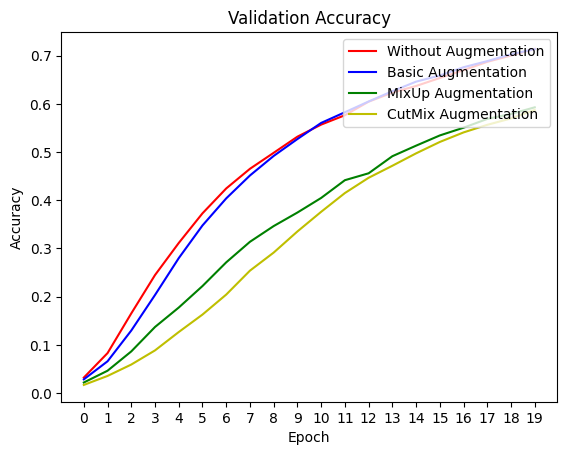

In [56]:
plt.plot(results_wo_aug['val_acc'], 'r', label="Without Augmentation")
plt.plot(results_basic_aug['val_acc'], 'b', label="Basic Augmentation")
plt.plot(results_mixup_aug['val_acc'], 'g', label="MixUp Augmentation")
plt.plot(results_cutmix_aug['val_acc'], 'y', label="CutMix Augmentation")

plt.title('Validation Accuracy')
plt.ylabel('Accuracy')
plt.xticks(list(range(EPOCH)))
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.savefig('val_acc.png')
plt.show()

### 3) 각 기법 적용 결과 예시

In [60]:
def visualize_aug_result(dataloader, num_images=3):    
    imgs, labels = next(iter(dataloader))
    imgs, labels = imgs[:num_images], labels[:num_images] # 앞에서부터 num_images만큼 선택    
    
    # MixUp 적용
    mixup_imgs, mixup_labels = mixup_efficient(imgs.clone(), labels.clone(), alpha=1.0, num_classes=120)
    
    # CutMix 적용
    cutmix_imgs, cutmix_labels = cutmix_efficient(imgs.clone(), labels.clone(), alpha=1.0, num_classes=120)

    # 시각화 설정 (3행 x num_images열)
    fig, axes = plt.subplots(3, num_images, figsize=(num_images * 4, 12))
    
    methods = [
        ('Basic', imgs),
        ('Mixup', mixup_imgs),
        ('Cutmix', cutmix_imgs)
    ]

    for row, (name, data) in enumerate(methods):
        for col in range(num_images):
            ax = axes[row, col]
            
            # Tensor (C, H, W) -> Numpy (H, W, C) 변환
            img = data[col].cpu().numpy().transpose(1, 2, 0)
            
            # Image Clipping (Normalize 때문에 0~1범위를 벗어날 수 있으므로)
            img = np.clip(img, 0, 1) if img.max() > 1 or img.min() < 0 else img
            
            ax.imshow(img)
            ax.set_title(f"{name} {col+1}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

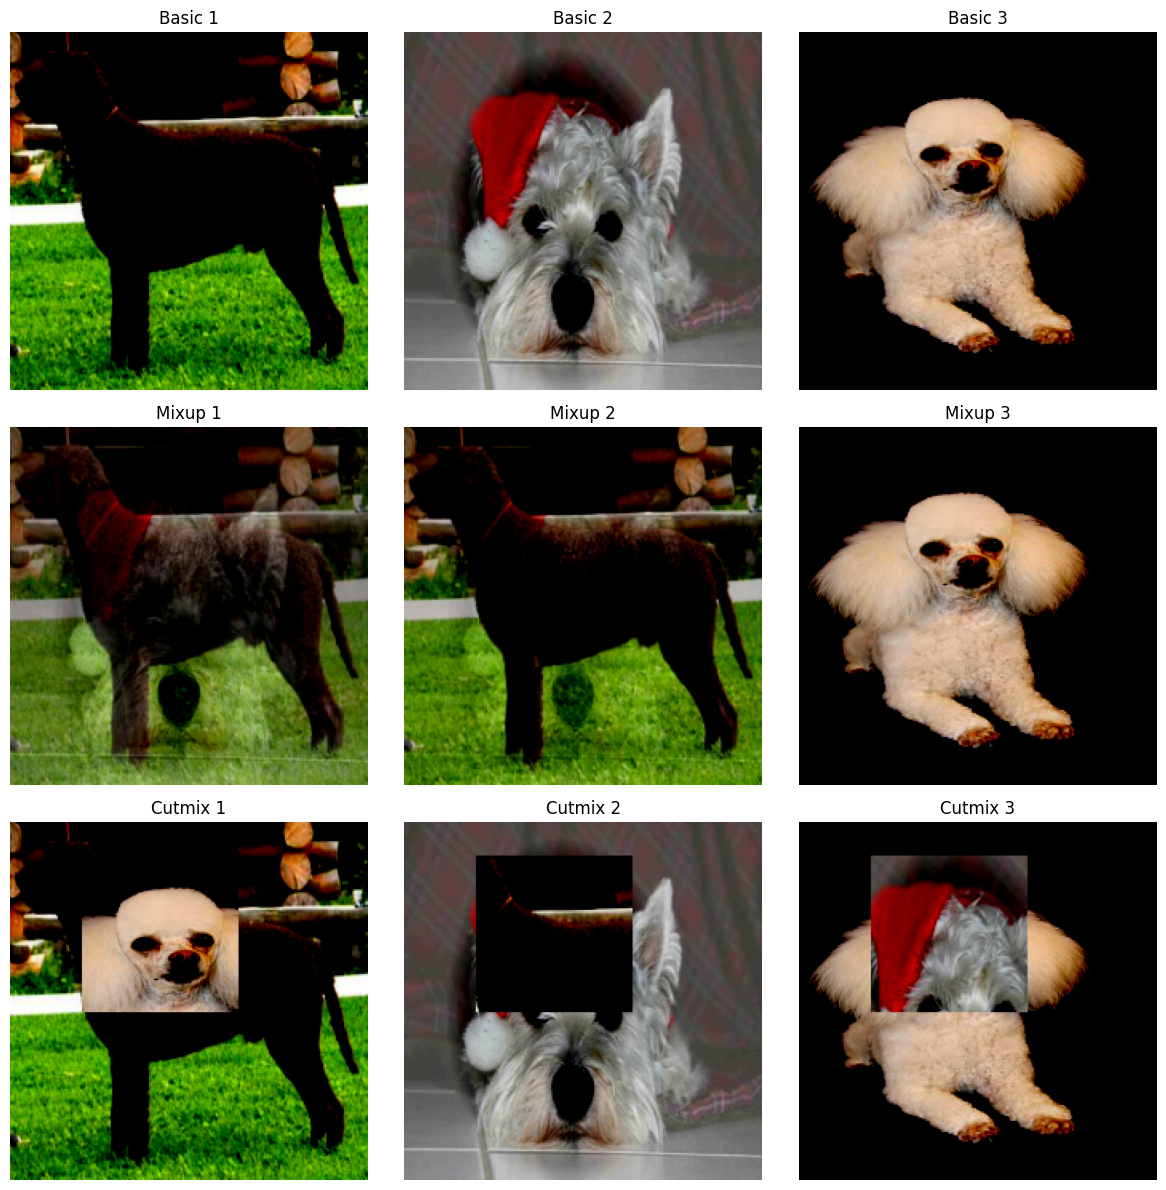

In [66]:
visualize_aug_result(trainloader_for_show, num_images=3)

### 4) 결과 분석

**모델 학습**  
- training loss는 4개의 모델 모두 점점 감소하는 것을 볼 수 있음  
&rarr; 각각의 ResNet 모델이 수렴하고 있는 것을 확인

**문제점**
- MixUp, CutMix와 같은 복잡한 augmentation 기법을 적용한 모델은 augmentation을 적용하지 않거나(w/o augmentation), 상대적으로 단순한 basic augmentation을 적용한 보델보다 수렴 속도가 느린 것을 볼 수 있음
- validation accuracy 역시 w/o augmentation, basic augmentation 적용 모델이
초기에 더 빠르게 상승하고, 에폭이 진행되는 동안 MixUp, CutMix 적용 모델보다 높은 accuracy 값을 가짐

**원인 분석**
- MixUp, CutMix 적용 모델의 validation Loss는 training loss보다 빨리 감소하고 있고  
validation accuracy가 train accuracy보다 높은 것을 볼 수 있음(위 모델 학습 cell에서 출력되는 값들 참고),  
&rarr; Mixup이나 CutMix 적용 시 위 시각화 이미지에서 볼 수 있듯이, 학습 데이터를 상대적으로 더 복잡한 형태로 변환했기 때문에 다른 경우보다 모델이 학습하기 어려워하여, training loss가 천천히 감소하지만 좀더 쉬운 validation 데이터에 대해서는 잘 맞추기 때문인 것으로 추정할 수 있음

**적용 방안**
- **충분한 학습(epoch 증가)**: MixUp, CutMix 적용 모델은 아직 수렴하지 않은 상태이므로, epoch을 충분히 준다면 training loss가 서서히 줄어들고 validation accuracy도 점점 증가하면서 좀더 성능이 올라갈 것으로 예상함
- **MixUp, CutMix 하이퍼 파라미터 조정**: 현재, MixUp, CutMix 적용 시 변환 정도를 강하게 (alpha=1.0) 주고 있기 때문에, 이를 작은 값으로 조정한다면 좀더 빠르게 수렴할 것으로 기대함
- **Learning Rate Scheduler (학습률 스케줄러) 조정**: MixUp, CutMix는 학습 데이터의 난이도가 높기 때문에, 초반에는 learning rate을 작은 값에서 서서히 올려서, 어려운 데이터에 대해 기울기가 폭주하는 것을 방지하여 안정적으로 학습이 진행될 수 있도록 보완할 수 있음


# 회고

- 초반에 노드 학습을 하면서, augmentation을 적용한 데이터를 원본 데이터(without augmentation)에 더해서 데이터의 양을 늘려야 하는 것(Offline Augmentation)이 아닌가 하는 의문이 들었다. 알아보니 파이토치는 온라인 증강(Online Augmentation)을 통해 메모리에 올라가는 양이 동일하더라도 augmentaton 데이터까지 본 것과 같은 효과를 얻는다고 한다.
- **DataLoader**가 매 에폭마다 배치를 만들기 위해 Dataset에 데이터를 **요청(호출)할 때마다, 그 순간순간마다 transform 코드가 새롭게 실행**. 하드디스크에 저장된 데이터는 '원본' 그대로 두고, 학습 시 데이터를 메모리로 불러올 때(DataLoader) 실시간으로 무작위 변형을 가해서 모델에 던져주는 방식  
&rarr; transform에 확률을 부여해서, 호출될 때마다 다른 데이터가 생성되고 결국에는 원본도 보고 학습한 효과라는 것
- 무조건 augmentation을 적용한다고 해서 성능이 올라간다고 생각하면 안 되고, 데이터의 특징이나 epoch에 따른 전반적인 학습 결과 등을 분석해서 기법을 적용해야 한다는 것을 배울 수 있었음